In [1]:
%load_ext autoreload
%autoreload 2
import warnings
warnings.filterwarnings('ignore')

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
import glob

import h5py
import flammkuchen as fl
import seaborn as sns
from matplotlib.cm import ScalarMappable
import scipy
from scipy import stats

from sklearn.preprocessing import MinMaxScaler

In [3]:
from megabouts_helper import labels_cat, color, color_bouts, cmp_bouts, color_ipsi_cont
from preprocess_helper import resort_ipsi_contra_traces, sort_ipsi_contra_arrays, reshape_feature_array

def get_ipsi_contra_col(df, col1, col2, ipsi_indicator_col):
    """
    Function to separate ipsilateral and contralateral fin durations.

    Parameters:
    df (pd.DataFrame): The DataFrame containing the data.
    col1 (str): The name of the first duration column (e.g., 'l_fin_duration').
    col2 (str): The name of the second duration column (e.g., 'r_fin_duration').
    ipsi_indicator_col (str): The name of the column indicating which fin is ipsi (0 for col1, 1 for col2).

    Returns:
    np.ndarray: Array of ipsilateral fin durations.
    np.ndarray: Array of contralateral fin durations.
    """
    # Determine ipsilateral and contralateral durations
    ipsi_fin_duration = np.where(df[ipsi_indicator_col] == 0, df[col1], df[col2])
    contra_fin_duration = np.where(df[ipsi_indicator_col] == 0, df[col2], df[col1])
    
    return ipsi_fin_duration, contra_fin_duration

In [4]:
plt.style.use("figures.mplstyle")

In [1]:
master_path = Path(r'\\portulab.synology.me\data\Kata\Processed_Data\tensor_data')

path_tensors = Path(master_path/ 'tensors'/ 'keypoint_angles_tensor.h5')
# path_tensors = Path(master_path/ 'tensors' /'tensor_ipsi_contra_pos.h5')
path_features = Path(master_path/ 'features_ipsi_contra.csv')
master_path, path_features

NameError: name 'Path' is not defined

In [6]:
save_figure_path = Path(r'\\portulab.synology.me\data\Kata\Figures_Paper\Figure_4')

In [7]:
### tail, fin 1, fin 2, left eye, right eye

traces =  fl.load(path_tensors)
traces.shape

(11063, 15, 50)

### Sort tensor according to ipsi/ contra

In [8]:
bodyparts= [ 'body', 'left_eye', 'right_eye', 'left_fin', 'right_fin', 'tail_0', 'tail_1', 'tail_2', 'tail_3', 'tail_4', 'tail_5', 'tail_6', 'tail_7', 'tail_8', 'tail_9']
len(bodyparts)

15

In [9]:
traces_l_fin = traces[:, 3, :]
traces_r_fin = traces[:, 4, :]

traces_tail = traces[:,5:, :]
traces_l_fin.shape, traces_r_fin.shape, traces_tail.shape

((11063, 50), (11063, 50), (11063, 10, 50))

### read in features

In [10]:
features = pd.read_csv(path_features)
features.head()

,Unnamed: 0.1,Unnamed: 0,exp,fish_id,bout_angle,cluster,frame_start,frame_end,bout_id_orig,mb_proba,...,ipsi_peak_vigor,contra_peak_vigor,ipsi_freqs,contra_freqs,ipsi_osc,contra_osc,ipsi_duration,contra_duration,ipsi_max_freqs,contra_max_freqs
0,0,0,13052024_visstim_2D_round,240513_f0,3.000171,0,18375,18410,78,0.806645,...,0.244681,0.164076,0.109756,0.105263,4,3,28.0,27.0,0.166667,0.166667
1,1,1,13052024_visstim_2D_round,240513_f0,1.649302,0,19461,19484,80,1.000000,...,0.163745,0.128555,0.119048,0.117647,2,2,19.0,15.0,0.250000,0.166667
2,2,2,13052024_visstim_2D_round,240513_f0,-0.861132,0,19661,19689,81,1.000000,...,0.219439,0.184779,0.104167,0.115385,3,2,27.0,16.0,0.125000,0.166667
3,3,3,13052024_visstim_2D_round,240513_f0,0.870591,0,20257,20292,84,1.000000,...,0.209418,0.198009,0.117647,0.117647,4,2,35.0,16.0,0.125000,0.166667
4,4,4,13052024_visstim_2D_round,240513_f0,2.231631,0,20824,20859,86,1.000000,...,0.220615,0.185247,0.103448,0.116667,3,3,22.0,23.0,0.125000,0.125000


In [11]:
clusters = features.cluster.astype(int)
leading_fin = features.leading_fin.values
ipsi_fin_values = features.ipsi_fin.values
ipsi_fin_values

array([1., 1., 1., ..., 0., 0., 1.])

In [12]:
tick_borders = []
add = 0
for i in range(11):
    n = features[features.cluster ==i].shape[0]
    add += n
    tick_borders.append(add)

print (tick_borders)

[1572, 2066, 4162, 5124, 6952, 9056, 10582, 10803, 10809, 11031, 11063]


### Sort fins

In [13]:
ipsi_fin, contra_fin = resort_ipsi_contra_traces(traces_l_fin, traces_r_fin, ipsi_fin_values)
ipsi_fin.shape, contra_fin.shape

((11063, 50), (11063, 50))

In [14]:
ipsi_fin_baseline_removed = ipsi_fin - ipsi_fin[:, 0, np.newaxis]
contra_fin_baseline_removed = contra_fin - contra_fin[:, 0, np.newaxis]

### Plot examples

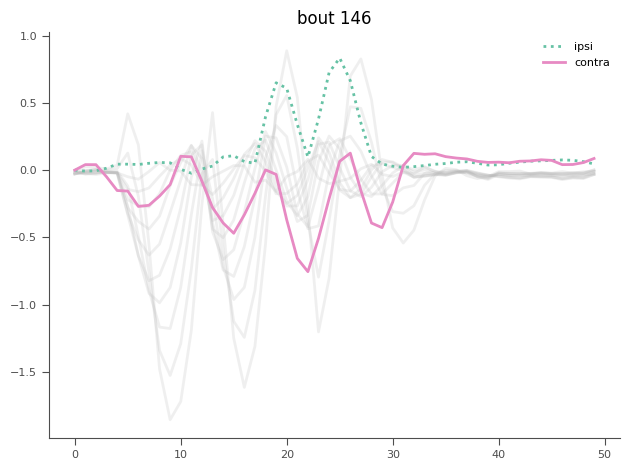

In [15]:
bout = np.random.randint(0, traces_tail.shape[0])

plt.figure()
plt.title(f'bout {bout}')
plt.plot(traces_tail[bout,:, :].T,alpha=0.2, c=color_ipsi_cont[-1])
plt.plot(ipsi_fin_baseline_removed[bout,:], label='ipsi', ls=':', c=color_ipsi_cont[0])
plt.plot(contra_fin_baseline_removed[bout,:], label='contra', c=color_ipsi_cont[1])
plt.legend()

plt.tight_layout()

### Cross correltaion and phase lag between tail segments

In [16]:
import scipy.signal

# Initialize a list to hold the lags
lags_full = []

for bout in range(traces_tail.shape[0]):
    lags = []
    # Loop over segments
    for i in range(traces_tail.shape[1]-1):
        # Calculate cross-correlation
        cross_corr = scipy.signal.correlate(traces_tail[bout, i,:],  traces_tail[bout, i+1,:], mode='full')
        # Find the index of the maximum correlation (peak of cross-correlation)
        peak_index = np.argmax(cross_corr)
        # Calculate lag
        # The 'zero lag' point is at the middle of the array (length of seg1 - 1)
        zero_lag_index = 50 - 1
        lag = peak_index - zero_lag_index
        lags.append(lag)
    lags_full.append(lags)


In [17]:
lags_full = np.asarray(lags_full)

In [18]:
lags_full[bout]

array([0, 0, 0, 0, 0, 0, 0, 0, 0], dtype=int64)

In [19]:
# Initialize a list to hold the lags
lags_full = []

for bout in range(traces_tail.shape[0]):
    cross_corr = scipy.signal.correlate(traces_tail[bout, 0,:],  traces_tail[bout, -1,:], mode='full')
    # Find the index of the maximum correlation (peak of cross-correlation)
    peak_index = np.argmax(cross_corr)
    # Calculate lag
    # The 'zero lag' point is at the middle of the array (length of seg1 - 1)
    zero_lag_index = 50 - 1
    lag = peak_index - zero_lag_index
    lags_full.append(lag)
lags_full = np.asarray(lags_full)
lags_full.shape

(11063,)

### Correlation of ipsi and contra fin with tail segments

In [20]:
import scipy.signal

tail_ispi_corr = np.full((traces_tail.shape[0], 10), np.nan)
tail_contra_corr = np.full((traces_tail.shape[0], 10), np.nan)
ispi_contra_corr = np.full((traces_tail.shape[0], 1), np.nan)

for bout in range(traces_tail.shape[0]):
    for seg in range(10):
        # Calculate the cross-correlation between each pair of the time series
        cross_tail_ipsi = np.corrcoef(traces_tail[bout, seg, :], ipsi_fin_baseline_removed[bout, :])
        cross_tail_contra = np.corrcoef(traces_tail[bout, seg, :], contra_fin_baseline_removed[bout, :])
        tail_ispi_corr[bout, seg] = cross_tail_ipsi[0][1]
        tail_contra_corr[bout, seg] = cross_tail_contra[0][1]
        
    cross_ipsi_contra = np.corrcoef(ipsi_fin_baseline_removed[bout, :], contra_fin_baseline_removed[bout, :])
    ispi_contra_corr[bout] = cross_ipsi_contra[0][1]

### Which segment is the highest correlated?

In [21]:
max_tail_ipsi = np.argmax(abs(tail_ispi_corr), axis=1)
max_tail_contra = np.argmax(abs(tail_contra_corr), axis=1)

In [22]:
np.argmax(abs(tail_contra_corr), axis=1)

array([1, 1, 1, ..., 0, 0, 4], dtype=int64)

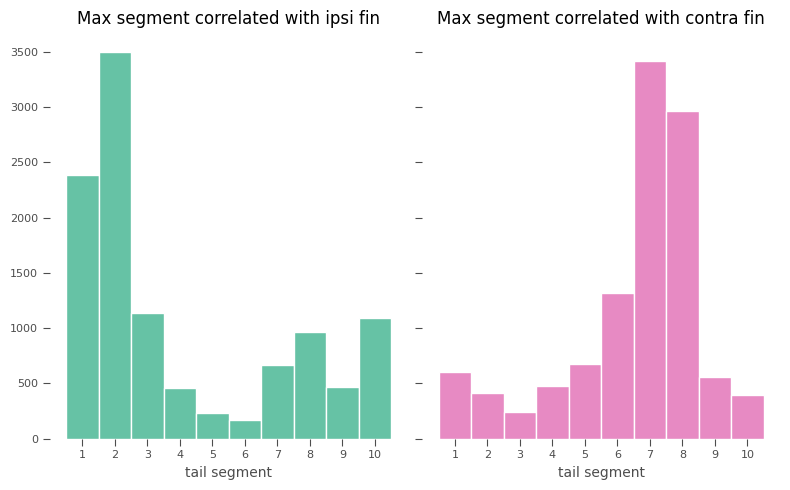

In [23]:
fig, axes = plt.subplots(1,2, figsize=(8,5), sharex=True, sharey=True)
axes = axes.ravel()

axes[0].hist(max_tail_ipsi, bins=np.arange(0, 11, 1), edgecolor='w', color=color_ipsi_cont[0])
axes[1].hist(max_tail_contra, bins=np.arange(0, 11, 1), edgecolor='w', color=color_ipsi_cont[1])

for ax in axes:
    ax.set_xticks(np.arange(0, 10, 1)+0.5)
    ax.set_xticklabels(np.arange(1, 11, 1))
    ax.set_xlabel('tail segment')

axes[0].set_title('Max segment correlated with ipsi fin')
axes[1].set_title('Max segment correlated with contra fin')

sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
fig.savefig(save_figure_path /'corr_segments_ipsi_contra_hist.pdf', dpi=300)
fig.savefig(save_figure_path /'corr_segments_ipsi_contra_hist.png', dpi=300)

### Plot corr per bout

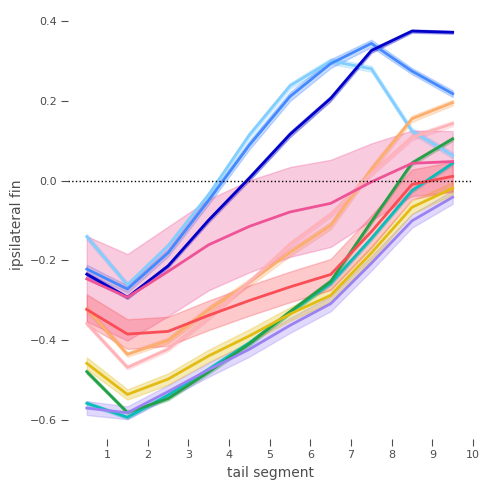

In [24]:
plt.figure(figsize =(5,5))

for clust in range(11):
    plt.plot(np.mean(tail_ispi_corr[clusters==clust], axis=0), c=color[clust], alpha= 1, label=labels_cat[clust])
    # Calculate mean and standard error
    mean_line = np.mean(tail_ispi_corr[clusters==clust], axis=0)
    stderr = np.std(tail_ispi_corr[clusters==clust], axis=0) / np.sqrt(tail_ispi_corr[clusters==clust].shape[0])

    # Plot confidence interval as a filled area
    plt.fill_between(np.arange(0,10,1), 
                     mean_line - stderr, 
                     mean_line + stderr, 
                     color=color[clust], 
                     alpha=0.3)
    
plt.axhline(0, lw=1, ls=':', c='k')
plt.xlabel('tail segment')
plt.xticks(np.arange(0, 10, 1)+0.5, labels=np.arange(1, 11, 1))
# plt.legend(title='bout category', loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('ipsilateral fin')
# plt.title ('correlation of tail segments with ipsilateral fin')
# plt.title ('correlation of tail segments with ipsilateral fin')
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()

plt.savefig(save_figure_path / 'corr_segments_ipsi_fin_bout_cat.pdf', dpi=300)
plt.savefig(save_figure_path / 'corr_segments_ipsi_fin_bout_cat.png', dpi=300)

In [25]:
tail_contra_corr.shape

(11063, 10)

In [31]:
f_size = 15

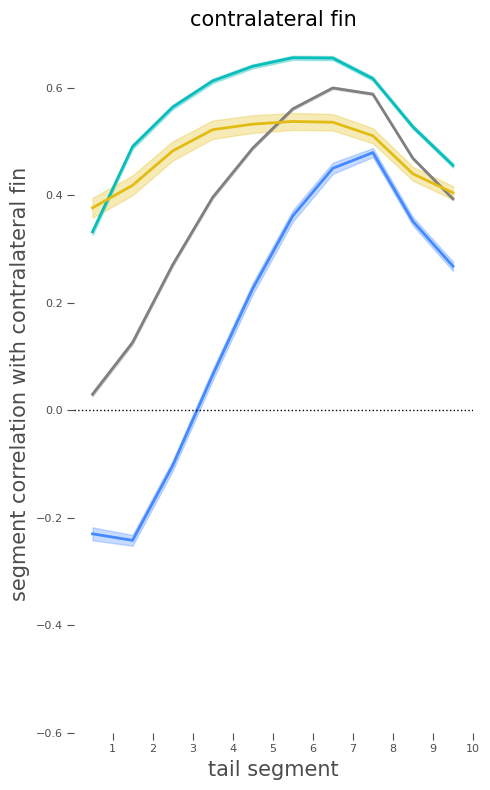

In [32]:
plt.figure(figsize =(5,8))

plt.plot(np.mean(tail_contra_corr, axis=0), c='gray', alpha= 1, label='all bouts')
mean_line = np.mean(tail_contra_corr, axis=0)
stderr = np.std(tail_contra_corr, axis=0) / np.sqrt(tail_contra_corr.shape[0])

# Plot confidence interval as a filled area
plt.fill_between(np.arange(0,10,1), 
             mean_line - stderr, 
             mean_line + stderr, 
             color='gray', 
             alpha=0.3)

for i, clust in enumerate([1, 5, 9]):
    plt.plot(np.mean(tail_contra_corr[clusters==clust], axis=0), c=color[clust], alpha= 1, label=labels_cat[clust])
    # Calculate mean and standard error
    mean_line = np.mean(tail_contra_corr[clusters==clust], axis=0)
    stderr = np.std(tail_contra_corr[clusters==clust], axis=0) / np.sqrt(tail_contra_corr[clusters==clust].shape[0])

    # Plot confidence interval as a filled area
    plt.fill_between(np.arange(0,10,1), 
                     mean_line - stderr, 
                     mean_line + stderr, 
                     color=color[clust], 
                     alpha=0.3)
    
plt.axhline(0, lw=1, ls=':', c='k')
plt.xlabel('tail segment', fontsize=f_size)
plt.xticks(np.arange(0, 10, 1)+0.5, labels=np.arange(1, 11, 1))
plt.ylabel('segment correlation with contralateral fin', fontsize=f_size)
plt.title ('contralateral fin', fontsize=f_size)
plt.ylim(-0.6, 0.7)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.savefig(save_figure_path / 'corr_segments_contra_fin_bout_cat_select.pdf', dpi=300)
plt.savefig(save_figure_path / 'corr_segments_contra_fin_bout_cat_select.png', dpi=300)

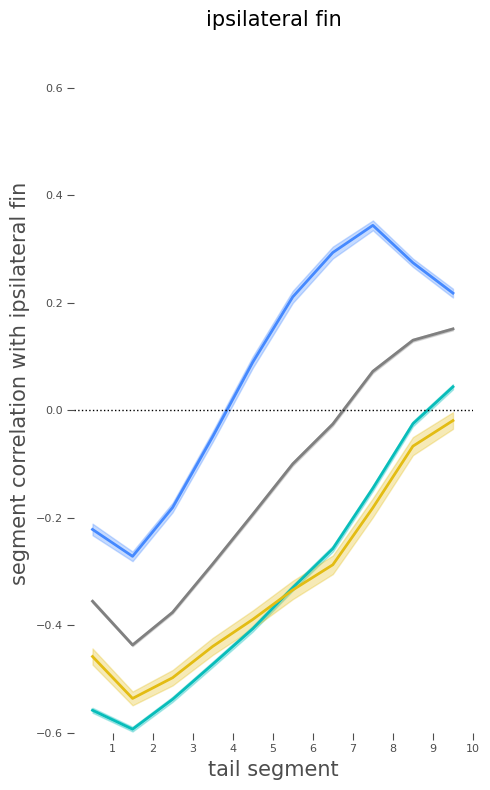

In [33]:
plt.figure(figsize =(5,8))

plt.plot(np.mean(tail_ispi_corr, axis=0), c='gray', alpha= 1, label='all bouts')
mean_line = np.mean(tail_ispi_corr, axis=0)
stderr = np.std(tail_ispi_corr, axis=0) / np.sqrt(tail_contra_corr.shape[0])

# Plot confidence interval as a filled area
plt.fill_between(np.arange(0,10,1), 
             mean_line - stderr, 
             mean_line + stderr, 
             color='gray', 
             alpha=0.3)

for i, clust in enumerate([1, 5, 9]):
    plt.plot(np.mean(tail_ispi_corr[clusters==clust], axis=0), c=color[clust], alpha= 1, label=labels_cat[clust])
    # Calculate mean and standard error
    mean_line = np.mean(tail_ispi_corr[clusters==clust], axis=0)
    stderr = np.std(tail_ispi_corr[clusters==clust], axis=0) / np.sqrt(tail_contra_corr[clusters==clust].shape[0])

    # Plot confidence interval as a filled area
    plt.fill_between(np.arange(0,10,1), 
                     mean_line - stderr, 
                     mean_line + stderr, 
                     color=color[clust], 
                     alpha=0.3)
    
plt.axhline(0, lw=1, ls=':', c='k')
plt.xlabel('tail segment', fontsize=f_size)
plt.xticks(np.arange(0, 10, 1)+0.5, labels=np.arange(1, 11, 1))
# plt.legend(title='bout category', loc='center left', bbox_to_anchor=(1, 0.5))
plt.ylabel('segment correlation with ipsilateral fin', fontsize=f_size)
# plt.title('segment correlation with contralateral fin')
plt.title ('ipsilateral fin', fontsize=f_size)
plt.ylim(-0.6, 0.7)
sns.despine(top=True, right=True, left=True, bottom=True)
plt.tight_layout()
plt.savefig(save_figure_path / 'corr_segments_ipsi_fin_bout_cat_select.pdf', dpi=300)
plt.savefig(save_figure_path / 'corr_segments_ipsi_fin_bout_cat_select.png', dpi=300)